In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,GradientBoostingClassifier,RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import files

In [172]:
uploaded = files.upload()


Saving Books.csv to Books.csv
Saving library_data.csv to library_data (2).csv
Saving Ratings.csv to Ratings.csv
Saving Users.csv to Users.csv


In [173]:
# Step 1: Load dataset
df = pd.read_csv("library_data.csv")


In [174]:

df.head()

,user_id,book_id,borrow_date,return_date,borrow_date.1,borrow_month,borrow_year,pages,reservation_status,overdue_status,user_role,book_category,book_holding_days
0,30,198,3/13/2023,3/29/2023,13,3,2023,456,True,1,student,non-fiction,16
1,68,45,4/2/2022,4/7/2022,2,4,2022,116,True,0,student,art,5
2,97,42,6/6/2023,6/8/2023,6,6,2023,102,True,0,faculty,history,2
3,86,69,10/5/2022,10/24/2022,5,10,2022,544,False,1,student,non-fiction,19
4,85,156,7/4/2020,7/9/2020,4,7,2020,107,False,0,student,fiction,5


In [175]:
# Step 2: Remove unnecessary fields

df = df.drop(columns=['return_date', 'reservation_status','overdue_status'])
df.head()

,user_id,book_id,borrow_date,borrow_date.1,borrow_month,borrow_year,pages,user_role,book_category,book_holding_days
0,30,198,3/13/2023,13,3,2023,456,student,non-fiction,16
1,68,45,4/2/2022,2,4,2022,116,student,art,5
2,97,42,6/6/2023,6,6,2023,102,faculty,history,2
3,86,69,10/5/2022,5,10,2022,544,student,non-fiction,19
4,85,156,7/4/2020,4,7,2020,107,student,fiction,5


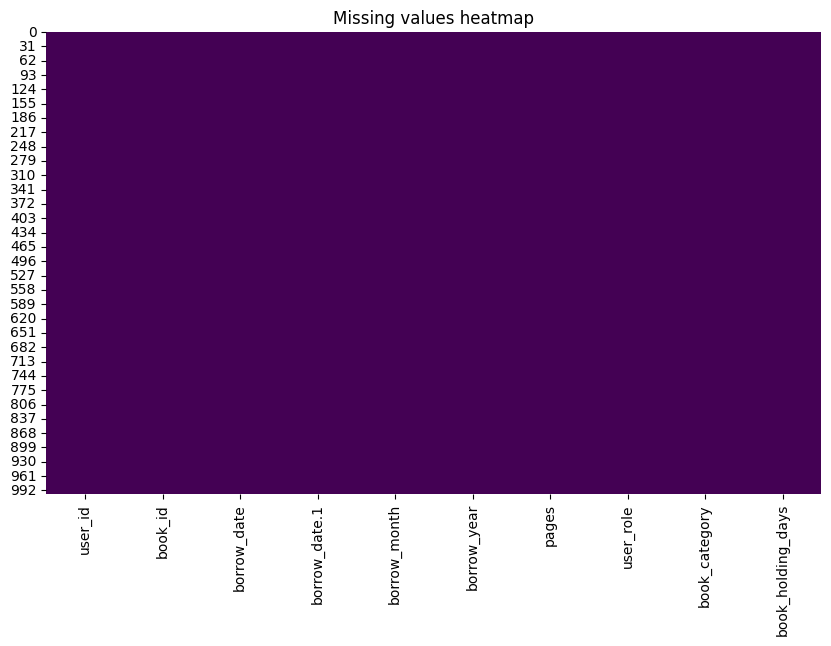

In [176]:
# Step 3: Heatmap for missing values (before any dropna or imputation)
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing values heatmap')
plt.show()

In [177]:
# Step 4: Convert borrow_date column to datetime format
df["borrow_date"] = pd.to_datetime(df["borrow_date"])

In [178]:
# Step 5: Encode categorical fields into numeric flags
def map_role(s):
    s = str(s).strip().lower()
    return [1 if s == "staff" else 0, 1 if s == "student" else 0]

def map_cat(s):
    s = str(s).strip().lower()
    return [
        1 if s == "fiction" else 0,
        1 if s == "history" else 0,
        1 if s in ("non-fiction", "non_fiction", "non fiction") else 0,
        1 if s == "science" else 0,
    ]


In [179]:
# Step 6: Build feature rows for model input
rows = []
for _, r in df.iterrows():
    role_staff, role_student = map_role(r["user_role"])
    cf, ch, cnf, cs = map_cat(r["book_category"])
    row = [
        float(r["pages"]),
        float(r["borrow_date"].dayofweek),
        float(r["borrow_date"].year),
        float(r["borrow_date"].month),
        role_staff, role_student,
        cf, ch, cnf, cs,
        int(r["user_id"]),
        int(r["book_id"])
    ]
    rows.append(row)



In [180]:
# Step 7: Convert features and target into NumPy arrays
X = np.array(rows, dtype=float)
y = df["book_holding_days"].astype(float).values

In [181]:
# Step 8: Define the feature order (to keep consistency during training & prediction)
feature_order = [
    "pages","day_val","year_val","month_val",
    "role_staff","role_student",
    "cat_fiction","cat_history","cat_non_fiction","cat_science",
    "user_id","book_id"
]


In [182]:
# Step 9: Split data into train and test sets (grouped by user_id)
groups = df["user_id"].astype(int).values
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

###XGBRegressor

In [183]:
# Step 10: Train machine learning models

rf  = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
xgbm = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.85, random_state=42,
    tree_method="hist", objective="reg:squarederror"
)

rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)
xgbm.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [184]:
# Step 11: Create a simple ensemble model
class Ensemble:
    def __init__(self, rf, gbr, xgb):
        self.rf, self.gbr, self.xgb = rf, gbr, xgb
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = np.column_stack([
            self.rf.predict(X),
            self.gbr.predict(X),
            self.xgb.predict(X)
        ])
        return preds.mean(axis=1)

ensemble = Ensemble(rf, gbr, xgbm)

In [186]:
# Step 12: Evaluate the ensemble model

pred = ensemble.predict(X_test)
print("Hybrid Ensemble Regressor Results")
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred)**0.5)
print("R2:", r2_score(y_test, pred))

Hybrid Ensemble Regressor Results
MAE: 0.6571605040904229
RMSE: 0.7958866344013708
R2: 0.9823423400357086


In [ ]:
# Step 13: Save the trained ensemble model for future use
bundle = {
    "model": ensemble,
    "feature_order": feature_order,
    "note": "Input must be a 12-length vector in listed order."
}
joblib.dump(bundle, 'return_days_model_fixed_features.pkl')

In [ ]:
files.download('return_days_model_fixed_features.pkl')

###RandomForestRegressor

In [187]:
df_RF = pd.read_csv("library_data.csv")

In [188]:
df_RF = df_RF.drop(columns=['borrow_date', 'return_date', 'reservation_status','overdue_status'])

In [189]:
df_RF.head()

,user_id,book_id,borrow_date.1,borrow_month,borrow_year,pages,user_role,book_category,book_holding_days
0,30,198,13,3,2023,456,student,non-fiction,16
1,68,45,2,4,2022,116,student,art,5
2,97,42,6,6,2023,102,faculty,history,2
3,86,69,5,10,2022,544,student,non-fiction,19
4,85,156,4,7,2020,107,student,fiction,5


In [190]:
df_dum = pd.get_dummies(df[["user_role", "book_category"]])


In [191]:
df_RF = pd.concat([df, df_dum], axis=1).drop(["user_role", "book_category"], axis=1)
df_RF.head()

,user_id,book_id,borrow_date,borrow_date.1,borrow_month,borrow_year,pages,book_holding_days,user_role_faculty,user_role_staff,user_role_student,book_category_art,book_category_fiction,book_category_history,book_category_non-fiction,book_category_science
0,30,198,2023-03-13,13,3,2023,456,16,False,False,True,False,False,False,True,False
1,68,45,2022-04-02,2,4,2022,116,5,False,False,True,True,False,False,False,False
2,97,42,2023-06-06,6,6,2023,102,2,True,False,False,False,False,True,False,False
3,86,69,2022-10-05,5,10,2022,544,19,False,False,True,False,False,False,True,False
4,85,156,2020-07-04,4,7,2020,107,5,False,False,True,False,True,False,False,False


In [192]:
X = df_RF.drop(columns=['book_holding_days'])
y = df_RF['book_holding_days']

In [193]:
dt_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
for c in dt_cols:
    X[c + "_year"]  = pd.to_datetime(X[c]).dt.year.astype("Int64")
    X[c + "_month"] = pd.to_datetime(X[c]).dt.month.astype("Int64")
    X[c + "_dow"]   = pd.to_datetime(X[c]).dt.dayofweek.astype("Int64")
X = X.drop(columns=dt_cols)

In [194]:
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols):
    X[bool_cols] = X[bool_cols].astype(int)

In [195]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[num_cols]

In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42,
    stratify=y if set(y.unique()) <= {0,1} else None
)

In [197]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

In [198]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [199]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [201]:

pred = rf_model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2   = r2_score(y_test, pred)


print("Random Forest Regressor Results")
print("Mean Absolute Error (MAE):", round(mae, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 4))


Random Forest Regressor Results
Mean Absolute Error (MAE): 8.683
Root Mean Squared Error (RMSE): 10.209
R² Score: -2.5411


###SVM (Support Vector Machine)

In [216]:
# Step 1: Load data
df_SVM = pd.read_csv("library_data.csv")



In [217]:
# Step 2: Drop leakage / unused columns
df_SVM = df_SVM.drop(
    columns=['borrow_date', 'return_date', 'reservation_status', 'overdue_status'],
    errors='ignore'
)



In [218]:
# Step 3: One-hot encode categoricals
df_dum = pd.get_dummies(df_SVM[["user_role", "book_category"]], drop_first=True)
df_SVM = pd.concat([df_SVM.drop(columns=["user_role", "book_category"]), df_dum], axis=1)

In [219]:
# Step 4: Create binary target (Overdue > 14 days)
df_SVM["overdue_14"] = (df_SVM["book_holding_days"] > 14).astype(int)

In [220]:
# Step 5: Define features (X) and target (y)
X = df_SVM.drop(columns=['book_holding_days', 'overdue_14'])
y = df_SVM["overdue_14"]



In [221]:
#  Step 6: Train/test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)



In [222]:
# Step 7: Scale numeric features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)


In [223]:

#  Step 8: Train SVM classifier
svm_clf = SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42)
svm_clf.fit(X_train_scaled, y_train)



SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

In [224]:
# Step 9: Predictions
y_pred = svm_clf.predict(X_test_scaled)
y_proba = svm_clf.predict_proba(X_test_scaled)[:, 1]



In [225]:
# Step 11: Regression-style metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print("SVM Results (regression-style on 0/1 labels)")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 4))

SVM Results (regression-style on 0/1 labels)
MAE: 0.035
RMSE: 0.187
R²: 0.8282


##Compare the accuracy of different models

=== Model Comparison ===
                              Model       MAE       RMSE        R2
0  SVM (0/1 classification metrics)  0.035000   0.187000  0.828200
1           Random Forest Regressor  8.683000  10.209000 -2.541100
2         Hybrid Ensemble Regressor  0.657161   0.795887  0.982342


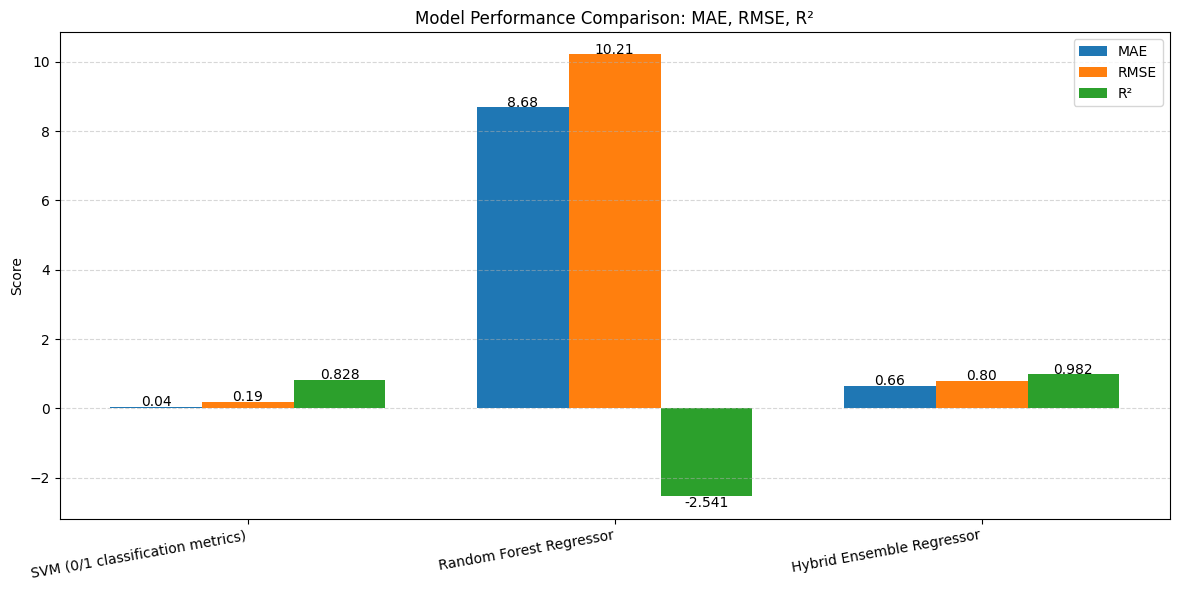

In [226]:

data = {
    "Model": [
        "SVM (0/1 classification metrics)",
        "Random Forest Regressor",
        "Hybrid Ensemble Regressor"
    ],
    "MAE":  [0.035, 8.683, 0.6571605040904229],
    "RMSE": [0.187, 10.209, 0.7958866344013708],
    "R2":   [0.8282, -2.5411, 0.9823423400357086]
}

df_cmp = pd.DataFrame(data)
print("=== Model Comparison ===")
print(df_cmp)


models = df_cmp["Model"].tolist()
mae_vals  = df_cmp["MAE"].values
rmse_vals = df_cmp["RMSE"].values
r2_vals   = df_cmp["R2"].values

x = np.arange(len(models))
w = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - w, mae_vals,  width=w, label="MAE")
plt.bar(x,     rmse_vals, width=w, label="RMSE")
plt.bar(x + w, r2_vals,   width=w, label="R²")

plt.xticks(x, models, rotation=10, ha="right")
plt.ylabel("Score")
plt.title("Model Performance Comparison: MAE, RMSE, R²")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)


for i, v in enumerate(mae_vals):  plt.text(i - w, v + (0.02 if v>=0 else -0.3), f"{v:.2f}", ha="center")
for i, v in enumerate(rmse_vals): plt.text(i,     v + (0.02 if v>=0 else -0.3), f"{v:.2f}", ha="center")
for i, v in enumerate(r2_vals):   plt.text(i + w, v + (0.02 if v>=0 else -0.3), f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


### Book Recommender







In [ ]:
# Step 1: Load dataset files
books = pd.read_csv('Books.csv')
users = pd.read_csv('Users.csv')
ratings = pd.read_csv('Ratings.csv')

In [ ]:
books.head(2)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...


In [ ]:
books['Book-Author'][1]

'Richard Bruce Wright'

In [ ]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [ ]:
books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [ ]:
users.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


In [ ]:
ratings.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [ ]:
books.duplicated().sum()

np.int64(0)

In [ ]:
ratings.duplicated().sum()

np.int64(0)

In [ ]:
users.duplicated().sum()

np.int64(0)

## Popularity Based Recommender System



In [ ]:
ratings_with_name = ratings.merge(books,on='ISBN')

In [ ]:
ratings_with_name.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...


In [ ]:
# Step 2: Count number of ratings per book
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [ ]:
# Step 3: Convert Book-Rating column to numeric (in case of bad values)
ratings_with_name['Book-Rating'] = pd.to_numeric(ratings_with_name['Book-Rating'], errors='coerce')

avg_rating_df = (ratings_with_name.groupby('Book-Title', as_index=False)['Book-Rating'].mean()
      .rename(columns={'Book-Rating': 'avg_rating'})
)

In [ ]:
# Step 4: Merge number of ratings with average rating per book
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [ ]:
# Step 5: Select top 10 popular books based on rating count and average rating
popular_df = popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(10)

In [ ]:
popular_df.head(2)

,Book-Title,num_ratings,avg_rating
80434,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
80422,Harry Potter and the Goblet of Fire (Book 4),387,5.824289


In [ ]:
# Step 6: Enrich popular books with author & cover image
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [ ]:
popular_df.head(2)

,Book-Title,Book-Author,Image-URL-M,num_ratings,avg_rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289


In [ ]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Collaborative Filtering Based Recommender System

In [ ]:
# Step 7: Identify active users (who have given more than 200 ratings)
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
padhe_likhe_users = x[x].index

In [ ]:
# Step 8: Keep only ratings from active users (200+ ratings)
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [ ]:
# Step 9: Identify famous books (with at least 50 ratings)
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books = y[y].index


In [ ]:
# Step 10: Keep only ratings of famous books (50+ ratings) by active users
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [ ]:
# Step 11: Create a pivot table (Book × User matrix)
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [ ]:
pt.fillna(0,inplace=True)

In [ ]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Step 12: Compute similarity scores between books
similarity_scores = cosine_similarity(pt)

In [ ]:
similarity_scores.shape

(706, 706)

In [ ]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:5]

    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))

        data.append(item)

    return data

In [ ]:
recommend('1984')

[['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg'],
 ["The Handmaid's Tale",
  'Margaret Atwood',
  'http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg'],
 ['Brave New World',
  'Aldous Huxley',
  'http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)',
  'ANNE RICE',
  'http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg']]

In [ ]:
pt.index[545]

"The Handmaid's Tale"

In [ ]:
pickle.dump(popular_df,open('popular.pkl','wb'))

In [ ]:
books.drop_duplicates('Book-Title')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [ ]:

books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')


pt.to_parquet('pt.parquet')
books.to_parquet('books.parquet')
popular_df.to_parquet('popular.parquet')

np.save('similarity_scores.npy', similarity_scores)

for f in ['pt.parquet','books.parquet','popular.parquet','similarity_scores.npy']:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>